In [ ]:
# EEG Preprocessing

This notebook focuses on preprocessing the EEG signal before epoching and ERP analysis.

The main steps will include:

1. Loading the raw recording
2. Selecting EEG and EOG channels
3. Inspecting the signals
4. Filtering
5. Handling bad channels and artifacts
6. Preparing the data for epoching

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
## 2. Load Raw Data

The continuous recording is loaded again because each notebook is designed to run independently.

In [3]:
from mne.datasets import sample

data_path = sample.data_path()

raw_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = mne.io.read_raw_fif(
    raw_file,
    preload=True
)

print(raw)

Opening raw data file C:\Users\DELL\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>


In [ ]:
## 3. Create a Working Copy

A copy of the raw recording is created so that preprocessing operations do not modify the original `raw` object.
    

In [4]:
raw_preprocessed = raw.copy()

In [ ]:
## 4. Select EEG and EOG Channels

The sample dataset contains both MEG and EEG recordings. For this project, only EEG and EOG channels are retained.

EOG is preserved because eye movements and blinks can introduce artifacts into EEG recordings.

In [7]:
raw_preprocessed.pick_types(
    eeg=True,
    eog=True
)

print(raw_preprocessed)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<Raw | sample_audvis_raw.fif, 60 x 166800 (277.7 s), ~79.3 MiB, data loaded>


In [8]:
print("Number of channels:", len(raw_preprocessed.ch_names))
print(raw_preprocessed.ch_names)

Number of channels: 60
['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060', 'EOG 061']


In [ ]:
## 5. Inspect EEG Before Preprocessing

The continuous EEG signal is inspected before filtering to understand the original signal quality.

Using matplotlib as 2D backend.


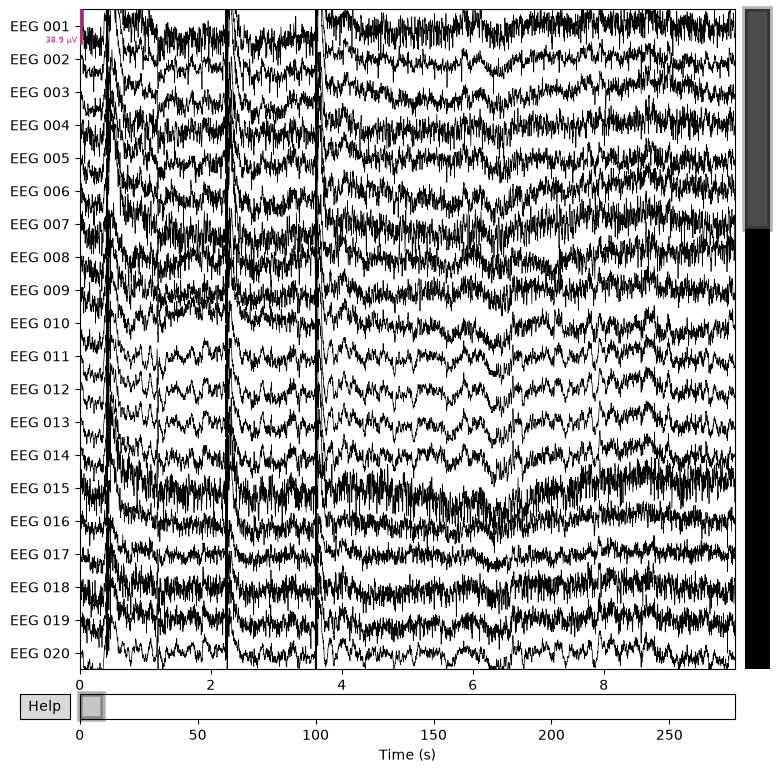

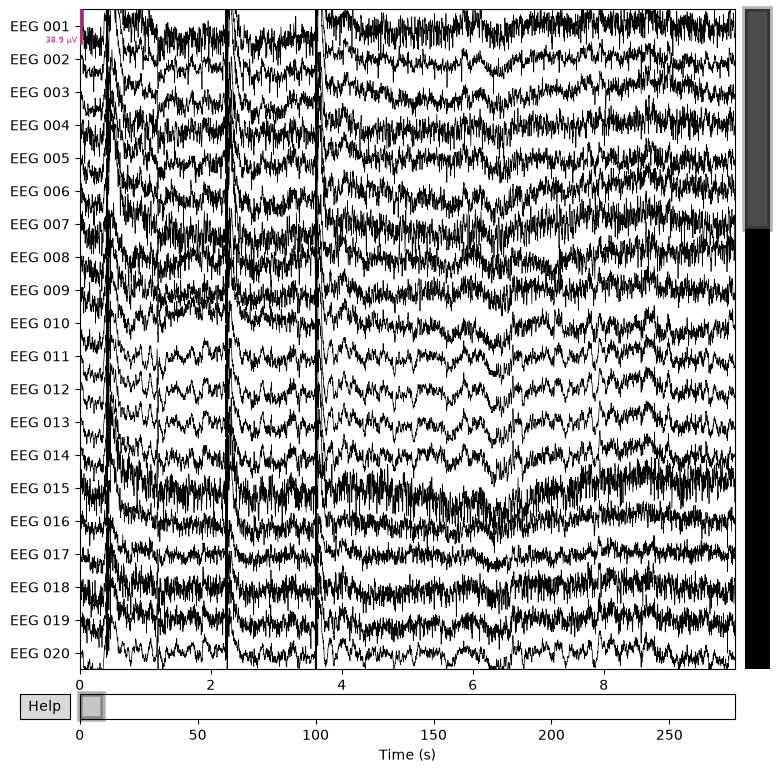

In [9]:
raw_preprocessed.plot(
    duration=10,
    n_channels=20,
    scalings="auto"
)

In [ ]:
## 6. Filter the EEG Signal

A band-pass filter is applied to retain frequencies between 0.1 and 40 Hz.

Filtering reduces very slow signal components and high-frequency activity/noise that are not the primary focus of this ERP analysis.

In [11]:
raw_preprocessed.filter(
    l_freq=0.1,
    h_freq=40.0
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)



<Raw | sample_audvis_raw.fif, 60 x 166800 (277.7 s), ~79.3 MiB, data loaded>

In [12]:
print("High-pass:", raw_preprocessed.info["highpass"], "Hz")
print("Low-pass:", raw_preprocessed.info["lowpass"], "Hz")

High-pass: 0.10000000149011612 Hz
Low-pass: 40.0 Hz


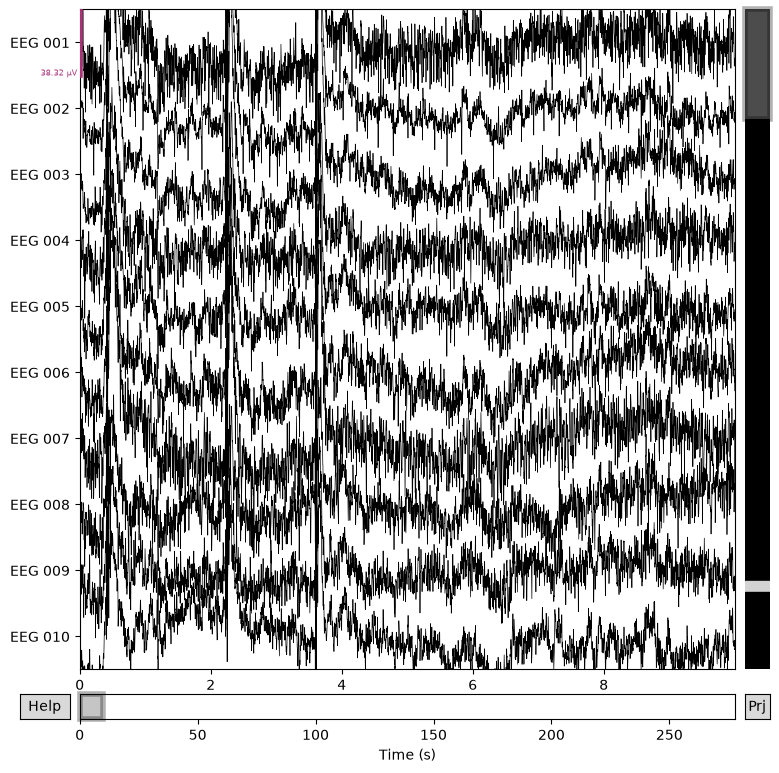

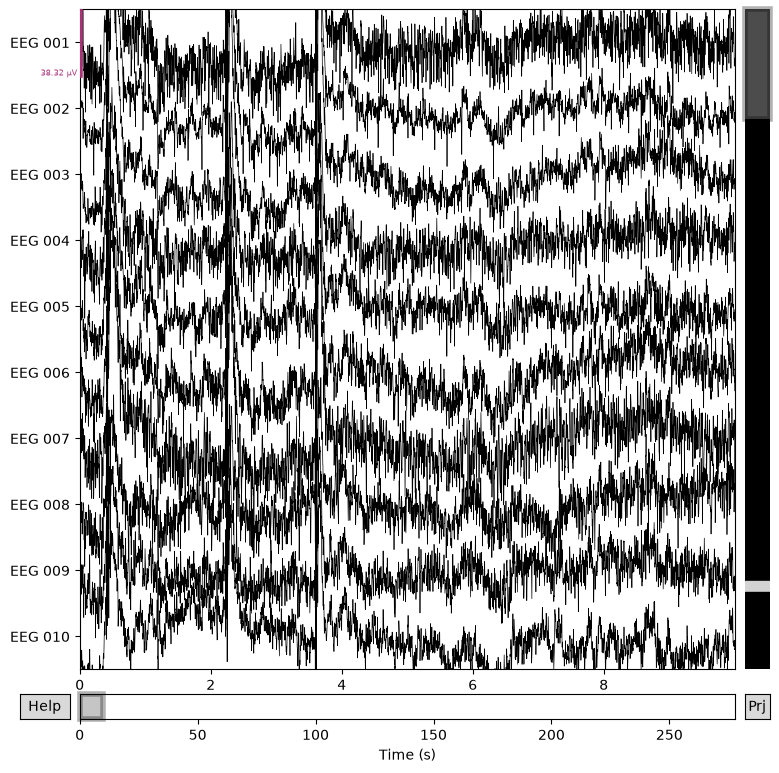

In [13]:
raw.plot(
    duration=10,
    n_channels=10,
    picks="eeg",
    scalings="auto",
    title="Before filtering"
)

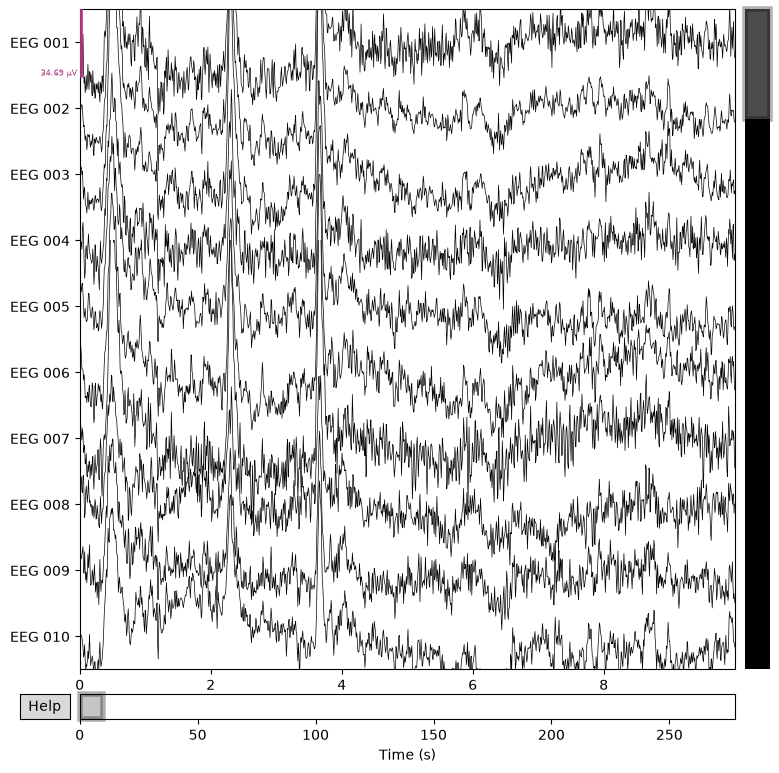

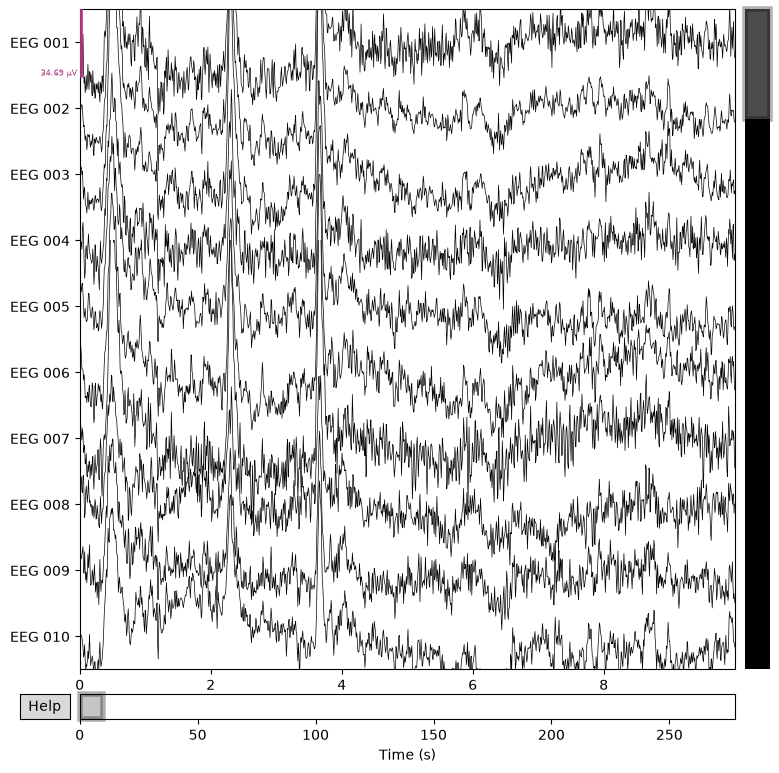

In [14]:
raw_preprocessed.plot(
    duration=10,
    n_channels=10,
    scalings="auto",
    title="After filtering"
)